Install Required Packages

In [ ]:
!pip install --upgrade transformers datasets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 22.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2024.12.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-c

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from transformers import BartTokenizer, BartForSequenceClassification, TrainingArguments, Trainer

# Optional: better error messages if needed
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

Dataset Splitting

In [ ]:
# Assumes `df` is already loaded with 'text' and 'label' columns
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

train_texts, train_labels = train_df['text'].tolist(), [int(x) for x in train_df['label']]
val_texts, val_labels = val_df['text'].tolist(), [int(x) for x in val_df['label']]
test_texts, test_labels = test_df['text'].tolist(), [int(x) for x in test_df['label']]

Recheck Label Types

In [ ]:
train_labels = [int(x) for x in train_labels]
val_labels = [int(x) for x in val_labels]
test_labels = [int(x) for x in test_labels]

Tokenization

In [ ]:
# Load tokenizer and apply to each split
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=512)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=512)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

Wrap into PyTorch Dataset Class

In [ ]:
class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Create datasets for training/validation/testing
train_dataset = MentalHealthDataset(train_encodings, train_labels)
val_dataset = MentalHealthDataset(val_encodings, val_labels)
test_dataset = MentalHealthDataset(test_encodings, test_labels)

Load Model

In [ ]:
model = BartForSequenceClassification.from_pretrained("facebook/bart-base", num_labels=3)

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Define Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./bart_cssrs_output",
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    do_train=True,
    do_eval=True,
    logging_steps=30,
    logging_dir="./logs",
    save_steps=9999999,
    save_total_limit=1,
    report_to="none"
)

Define Evaluation Metric

In [ ]:
def compute_metrics(pred):
    try:
        logits = pred.predictions
        if isinstance(logits, tuple):
            logits = logits[0]
        preds = np.argmax(logits, axis=1)
        labels = pred.label_ids
        accuracy = (preds == labels).mean()
        return {"accuracy": accuracy}
    except Exception as e:
        print("compute_metrics error:", e)
        return {"accuracy": -1}

Create Trainer

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Evaluate on Test Set

In [ ]:
print("Test Set Evaluation")
trainer.evaluate(test_dataset)

Test Set Evaluation


{'eval_loss': 1.045599102973938,
 'eval_model_preparation_time': 0.003,
 'eval_accuracy': 0.5,
 'eval_runtime': 1.2441,
 'eval_samples_per_second': 24.114,
 'eval_steps_per_second': 6.43}

Install Fairlearn

In [ ]:
!pip install fairlearn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 9.6 MB/s eta 0:00:00


Fairness Evaluation, Group Metrics, and Visualization

🔍 Fairness Evaluation: One-vs-Rest (DPD & EOD)

🔹 Class 0 vs Rest:
  Attribute: gender_binary
    → Demographic Parity Difference (DPD): 0.1333
    → Equalized Odds Difference (EOD):    0.2500
  Attribute: age_binary
    → Demographic Parity Difference (DPD): 0.0000
    → Equalized Odds Difference (EOD):    0.0000

🔹 Class 1 vs Rest:
  Attribute: gender_binary
    → Demographic Parity Difference (DPD): 0.0000
    → Equalized Odds Difference (EOD):    0.2500
  Attribute: age_binary
    → Demographic Parity Difference (DPD): 0.0000
    → Equalized Odds Difference (EOD):    0.0000

🔹 Class 2 vs Rest:
  Attribute: gender_binary
    → Demographic Parity Difference (DPD): 0.1333
    → Equalized Odds Difference (EOD):    0.3500
  Attribute: age_binary
    → Demographic Parity Difference (DPD): 0.0000
    → Equalized Odds Difference (EOD):    0.0000

📊 Group-wise Performance (Accuracy & Macro-F1):

Protected Feature: gender_binary
               accuracy  macro_f1
gender_binary                

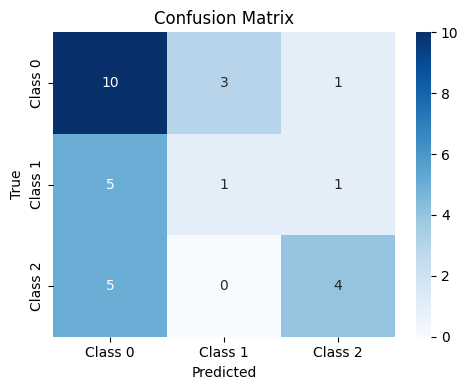

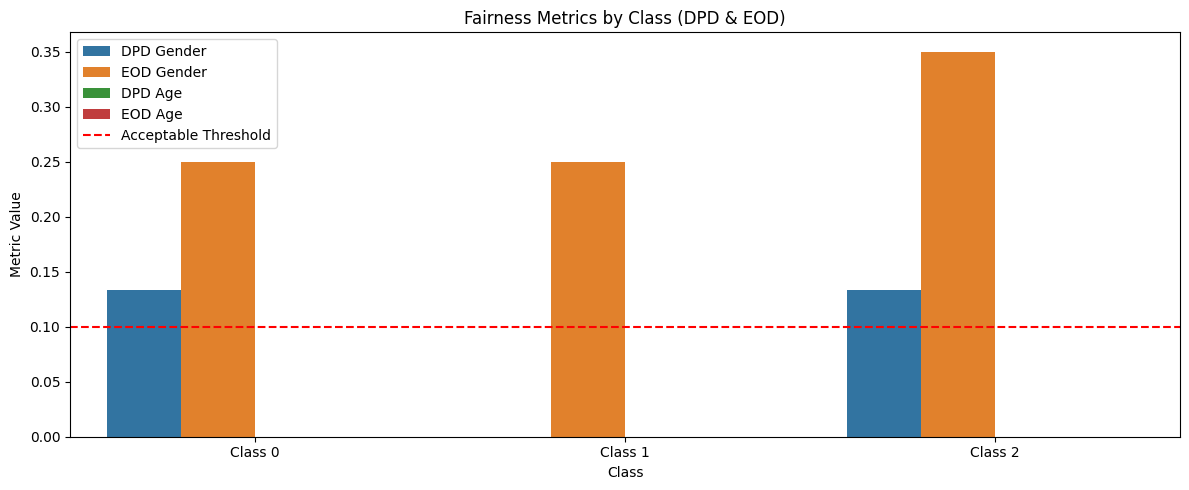

In [ ]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare test_df with predictions and true labels
test_df = test_df.copy()
test_df["true"] = true_labels
test_df["prediction"] = preds

# Binarize sensitive features if not already present
if "gender_binary" not in test_df.columns:
    test_df["gender_binary"] = (test_df["gender"] == "male").astype(int)
if "age_binary" not in test_df.columns:
    test_df["age_binary"] = (test_df["age_group"] == "adult").astype(int)

# Convert labels for fairlearn
y_true = test_df["true"].to_numpy()
y_pred = test_df["prediction"].to_numpy()

# 🔍 Fairness Evaluation by Class
print("🔍 Fairness Evaluation: One-vs-Rest (DPD & EOD)")
for class_id in [0, 1, 2]:
    y_true_bin = (y_true == class_id).astype(int)
    y_pred_bin = (y_pred == class_id).astype(int)

    print(f"\n🔹 Class {class_id} vs Rest:")
    for attr in ["gender_binary", "age_binary"]:
        dpd = demographic_parity_difference(y_true_bin, y_pred_bin, sensitive_features=test_df[attr])
        eod = equalized_odds_difference(y_true_bin, y_pred_bin, sensitive_features=test_df[attr])

        print(f"  Attribute: {attr}")
        print(f"    → Demographic Parity Difference (DPD): {dpd:.4f}")
        print(f"    → Equalized Odds Difference (EOD):    {eod:.4f}")

# 📊 Group-wise Accuracy and F1
print("\n📊 Group-wise Performance (Accuracy & Macro-F1):")
metrics = {
    "accuracy": lambda y_true, y_pred: (y_true == y_pred).mean(),
    "macro_f1": lambda y_true, y_pred: classification_report(y_true, y_pred, output_dict=True, zero_division=0)["macro avg"]["f1-score"]
}
for attr in ["gender_binary", "age_binary"]:
    print(f"\nProtected Feature: {attr}")
    mf = MetricFrame(metrics=metrics, y_true=y_true, y_pred=y_pred, sensitive_features=test_df[attr])
    print(mf.by_group)

# 📉 Confusion Matrix
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# 📊 Bar Plot of Fairness Metrics Per Class
class_names = ['Class 0', 'Class 1', 'Class 2']
metrics_data = []

for class_label, class_name in enumerate(class_names):
    y_true_bin = (y_true == class_label).astype(int)
    y_pred_bin = (y_pred == class_label).astype(int)

    dpd_gender = demographic_parity_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["gender_binary"])
    eod_gender = equalized_odds_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["gender_binary"])

    dpd_age = demographic_parity_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["age_binary"])
    eod_age = equalized_odds_difference(y_true_bin, y_pred_bin, sensitive_features=test_df["age_binary"])

    metrics_data.extend([
        {'Class': class_name, 'Metric': 'DPD Gender', 'Value': dpd_gender},
        {'Class': class_name, 'Metric': 'EOD Gender', 'Value': eod_gender},
        {'Class': class_name, 'Metric': 'DPD Age', 'Value': dpd_age},
        {'Class': class_name, 'Metric': 'EOD Age', 'Value': eod_age},
    ])

metrics_df = pd.DataFrame(metrics_data)
plt.figure(figsize=(12, 5))
sns.barplot(data=metrics_df, x='Class', y='Value', hue='Metric')
plt.title("Fairness Metrics by Class (DPD & EOD)")
plt.axhline(0.1, color='red', linestyle='--', label='Acceptable Threshold')
plt.ylabel("Metric Value")
plt.tight_layout()
plt.legend()
plt.show()